# Experiment with the plotting class object and its methods

Load the auxillary datasets for Amundsen Sea Embayment

In [ ]:
%reload_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
sys.path.append('../')
from src.plotting import Plotting
from src.utilities import load_ase_datasets

aux_data = load_ase_datasets()
xs_ase, ys_ase = aux_data['coords']['xs'], aux_data['coords']['ys']
print("Keys of the auxiliary data dictionary:", aux_data.keys())


  [load_ase_datasets] Loading reference coordinates …
  [load_ase_datasets] Loading Bedmap3 …
  [load_ase_datasets] Computing Tpmp …
  [load_ase_datasets] Computing surface slope …
  [load_ase_datasets] Loading velocity …
  [load_ase_datasets] Loading domain mask …
  [load_ase_datasets] All datasets ready.
Keys of the auxiliary data dictionary: dict_keys(['coords', 'sdem', 'bed', 'H', 'Tpmp', 'slope_x', 'slope_y', 'slope_mag', 'vx', 'vy', 'vel', 'mask'])


In [ ]:
import scipy.io
import numpy as np
import os
import torch
import sys
import pandas as pd
from src.ice import compute_pmp, enthalpy_to_temperature
from src.utilities import low_high_marginal_percentile, reverse_standardize


data_path        = os.getenv('RAW_DATA_PATH')
param_path       = os.getenv('PARAM_PATH')
inference_path   = os.getenv('INFERENCE_READY_DATA_PATH')
posterior_path   = os.getenv('POSTERIOR_PATH')

folder = data_path
nx, ny = 256, 256

# ---------------------------------------------------------------
# INPUT DATA - BASAL ENTHALPY AND GHF 
# ---------------------------------------------------------------
posterior_sample = "samples/hmc_md_beta3_betaw0.01.pt.npy"
H_filename       = 'H_gridded.mat'
Eb_mean_filename = 'trainingAll_Eb_sim_mean.mat' # for reverse standardization
Eb_std_filename  = 'trainingAll_Eb_sim_std.mat'
# ---------------------------------------------------------------
# ---------------------------------------------------------------

preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]

posterior_sample_path = os.path.join(posterior_path, posterior_sample)
GHF_sample_path       = os.path.join(posterior_path, "../GHF/inferred-GHF.npy")

GHF_samples           = np.load(GHF_sample_path)
posterior_samples     = np.load(posterior_sample_path)
num_Eb_samples        = posterior_samples.shape[0]
num_GHF_samples       = GHF_samples.shape[0]

#### basal temeprature

In [ ]:
# compute pmp
H_data = scipy.io.loadmat(os.path.join(folder, H_filename))

H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()
pmp = compute_pmp(H)

# load standardization factors for reverse standardization
Eb_mean          = scipy.io.loadmat(os.path.join(folder, Eb_mean_filename))
Eb_std           = scipy.io.loadmat(os.path.join(folder, Eb_std_filename))
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# ── Convert to temperature ─────────────────────────────────────────────
Tb_samples = np.zeros_like(posterior_samples)

for i in range(num_Eb_samples):
    Eb_i   = torch.from_numpy(posterior_samples[i])
    Tpmp_i = torch.from_numpy(pmp) if isinstance(pmp, np.ndarray) else pmp
    # reverse standardization
    Eb_i_ori = reverse_standardize(Eb_i,
                                   Eb_mean, 
                                   Eb_std, 
                                   method='relaxation',
                                   epsilon=Eb_standardize_epsilon)
    Tb_samples[i] = enthalpy_to_temperature(Eb_i_ori, Tpmp_i).numpy()

# ── Statistics ────────────────────────────────────────────────────────
Tb_std  = np.std(Tb_samples,  axis=0).reshape(nx, ny)
Tb_mean = np.mean(Tb_samples, axis=0).reshape(nx, ny)
Tb_low, Tb_high = low_high_marginal_percentile(Tb_samples, low_percentile=5, high_percentile=95)
Tb_low  = Tb_low.reshape(nx, ny)
Tb_high = Tb_high.reshape(nx, ny)

dTpmp_mean = pmp.reshape(nx, ny) - Tb_mean
dTpmp_low  = pmp.reshape(nx, ny) - Tb_low
dTpmp_high = pmp.reshape(nx, ny) - Tb_high


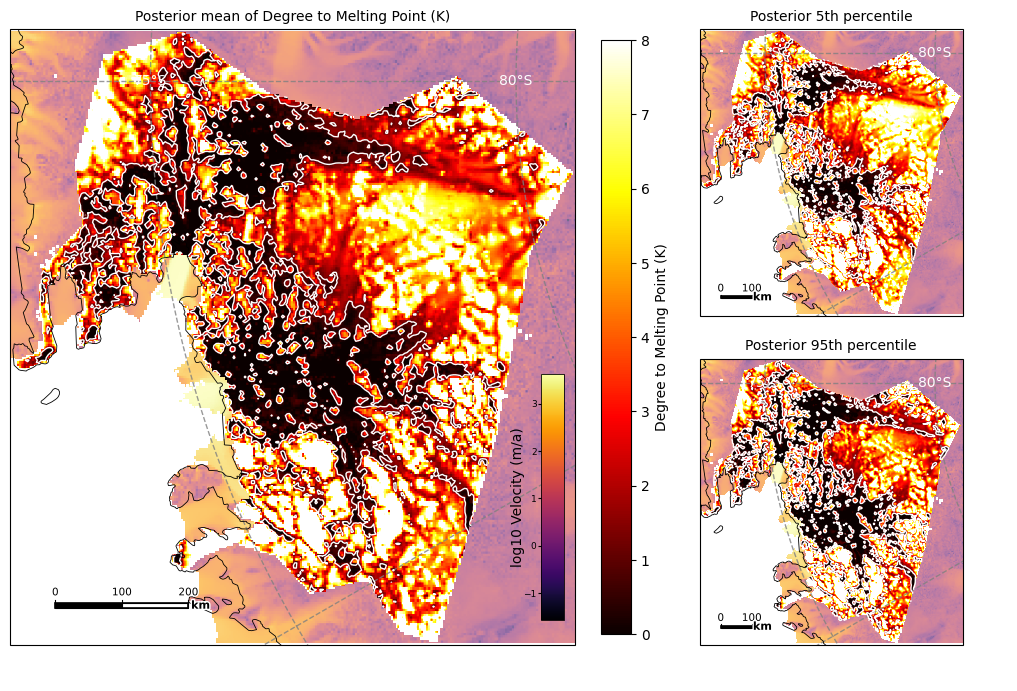

In [73]:
plotit = Plotting()
dTmax_level = 8

dTpmp_mean[aux_data['mask']==0] = np.nan
dTpmp_low[aux_data['mask']==0]  = np.nan
dTpmp_high[aux_data['mask']==0] = np.nan

posterior_mean = dict(
    x = xs_ase,
    y = ys_ase,
    data = dTpmp_mean,
    vmin = 0,
    vmax = dTmax_level,
    contour_data = dTpmp_mean, 
    contour_levels = [1],
    contour_colors = ['white'],
    cmap = 'hot',
    title = 'Posterior mean of Degree to Melting Point (K)',
    cb_label = 'Degree to Melting Point (K)',
    scalebar = (200, 2) # scale bar in km and number of segmentsbackground
)
posterior_lower = dict(
    x = xs_ase,
    y = ys_ase,
    data = dTpmp_low,
    vmin = 0,
    vmax = dTmax_level,
    cmap = 'hot',
    contour_data = dTpmp_low, 
    contour_levels = [1],
    contour_colors = ['white'],
    title = 'Posterior 5th percentile',
    colorbar = 'off',
    scalebar = (100, 1)
)
posterior_higher = dict(
    x = xs_ase,
    y = ys_ase,
    data = dTpmp_high,
    vmin = 0,
    vmax = dTmax_level,
    cmap = 'hot',
    contour_data = dTpmp_high,
    contour_levels = [1],
    contour_colors = ['white'],
    title = 'Posterior 95th percentile',
    colorbar = 'off',
    scalebar = (100, 1) 
)
background = dict(
    x = xs_ase,
    y = ys_ase,
    data = np.log10(aux_data['vel']),
    # use hillshade colormap for background
    cmap = 'inferno',
    cb_label = 'log10 Velocity (m/a)',
)

plotit.define_extent(xs_ase, ys_ase)
fig = plotit.plot(data = (posterior_mean, posterior_lower, posterior_higher), 
                  background= background,
                  layout = 'main+stack')

# save the figure
fig.savefig("../figs/posterior_5-mean-95_oficial.png", dpi=300, bbox_inches='tight')

#### Geothermal Heat Flux


In [ ]:
from pyproj import Transformer
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.mpl.geoaxes as geoaxes
import numpy as np
import pandas as pd

GHF_samples = GHF_samples * 1e3 # convert from W/m^2 to mW/m^2

ghf_low, ghf_high = low_high_marginal_percentile(GHF_samples, low_percentile=5, high_percentile=95)
ghf_low = ghf_low.reshape(nx, ny) 
ghf_high = ghf_high.reshape(nx, ny) 

ghf_mean = np.mean(GHF_samples, axis=0).reshape(nx, ny)

In [105]:
# make the same plot, but for GHF
plotit_ghf = Plotting()
ghf_max_level = 150
ghf_min_level = 50

ghf_levels = [80, 100, 120, 140]
ghf_colormap = "cividis"

ghf_mean[aux_data['mask']==0] = np.nan
ghf_low[aux_data['mask']==0]  = np.nan
ghf_high[aux_data['mask']==0] = np.nan

posterior_mean = dict(
    x = xs_ase,
    y = ys_ase,
    data = ghf_mean,
    vmin = ghf_min_level,
    vmax = ghf_max_level,
    contour_data = ghf_mean, 
    contour_levels = ghf_levels,
    contour_colors = ['white'],
    cmap = ghf_colormap,
    title = 'Posterior mean of GHF',
    cb_label = 'Geothermal Heat Flux (mW/m²)',
    scalebar = (200, 2), # scale bar in km and number of segmentsbackground
    contour_labels = True,
    contour_label_fontsize = 12
)
# troubleshoot = dict( # this makes a blank plot so that we can see the background data
#     x = xs_ase,
#     y = ys_ase,
#     data = np.nan * np.ones_like(ghf_mean),
#     cmap = ghf_colormap,
#     title = 'Posterior mean of GHF',
#     cb_label = 'Geothermal Heat Flux (mW/m²)',
#     scalebar = (200, 2), # scale bar in km and number of segmentsbackground
#     contour_labels = True,
#     contour_label_fontsize = 12
# )
posterior_lower = dict(
    x = xs_ase,
    y = ys_ase,
    data = ghf_low,
    vmin = ghf_min_level,
    vmax = ghf_max_level,
    cmap = ghf_colormap,
    contour_data = ghf_low, 
    contour_levels = ghf_levels,
    contour_colors = ['white'],
    title = 'Posterior 5th percentile',
    colorbar = 'off',
    scalebar = (100, 1),
    contour_labels = True,
    contour_label_fontsize = 9
)
posterior_higher = dict(
    x = xs_ase,
    y = ys_ase,
    data = ghf_high,
    vmin = ghf_min_level,
    vmax = ghf_max_level,
    cmap = ghf_colormap,
    contour_data = ghf_high,
    contour_levels = ghf_levels,
    contour_colors = ['white'],
    title = 'Posterior 95th percentile',
    colorbar = 'off',
    scalebar = (100, 1),
    contour_labels = True,
    contour_label_fontsize = 9
)
background = dict(
    x = xs_ase,
    y = ys_ase,
    data = np.log10(aux_data['vel']),
    # use hillshade colormap for background
    cmap = 'inferno',
    cb_label = 'log10 Velocity (m/a)',
)


plotit_ghf.define_extent(xs_ase, ys_ase)

#### Load the volcano datasets

Volcanoes after confidence filter: 178
Volcanoes inside model domain:     47


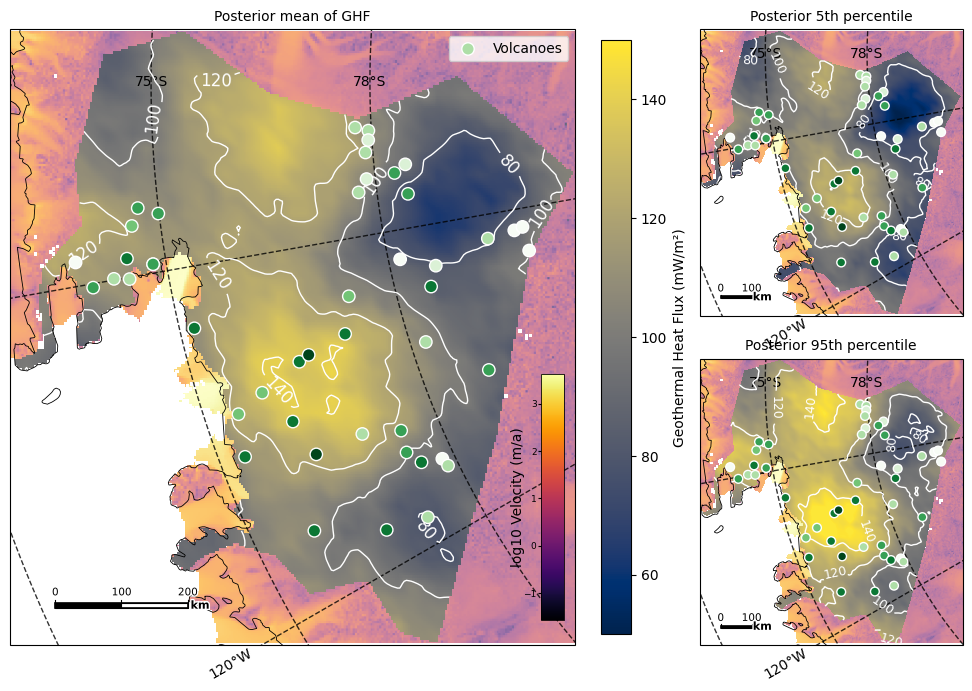

In [108]:
# ── Load and filter by confidence ────────────────────────────────────────
volcano_path = "../data/other-inputs/vanWykDeVries2017_Table2_subglacial_cones.csv"
volcano      = pd.read_csv(volcano_path)

confidence_threshold = 1
lat_correction = 0.25 # the csv data appear to be 0.25 degree closer to south pole
conf_mask    = volcano['Confidence_Sum'].values >= confidence_threshold
volcano_lat  = volcano['Latitude'].values[conf_mask] + lat_correction
volcano_lon  = volcano['Longitude'].values[conf_mask]
volcano_conf = volcano['Confidence_Sum'].values[conf_mask]

# ── Project lat/lon → polar stereographic (same as model grid) ───────────
data_proj_string = plotit_ghf.data_crs.proj4_init  # or .to_wkt()

transformer_correct = Transformer.from_crs(
    "epsg:4326",
    data_proj_string,            
    always_xy=True
)
volcano_x, volcano_y = transformer_correct.transform(volcano_lon, volcano_lat)

# ── Find which volcanoes fall inside the model domain ────────────────────
X_md, Y_md  = np.meshgrid(xs_ase, ys_ase)
grid_points = np.column_stack((X_md.flatten(), Y_md.flatten()))

domain_at_volcanoes = griddata(
    grid_points,
    aux_data['mask'].flatten(),
    np.column_stack((volcano_x, volcano_y)),
    method='nearest'
)
volcano_in_domain    = domain_at_volcanoes.astype(bool)
volcano_x_in_domain  = volcano_x[volcano_in_domain]
volcano_y_in_domain  = volcano_y[volcano_in_domain]
volcano_conf_in_domain = volcano_conf[volcano_in_domain]

print(f"Volcanoes after confidence filter: {len(volcano_lat)}")
print(f"Volcanoes inside model domain:     {len(volcano_x_in_domain)}")

plt.close('all')
fig = plotit_ghf.plot(data=(posterior_mean, posterior_lower, posterior_higher),
                      background=background,
                      layout='main+stack')

for ax in fig.axes:
    if not isinstance(ax, geoaxes.GeoAxes):
        continue

    scatter_size  = 80 if ax.get_label() == 'main' else 40
    volcano_label = 'Volcanoes' if ax.get_label() == 'main' else None

    ax.scatter(
        volcano_lon[volcano_in_domain],   # ← raw longitude degrees
        volcano_lat[volcano_in_domain],   # ← raw latitude degrees
        c=volcano_conf_in_domain,
        cmap='Greens',
        edgecolor='white',
        s=scatter_size,
        zorder=10,
        label=volcano_label,
        transform=ccrs.PlateCarree()      # ✅ cartopy reprojects internally
    )
    if volcano_label:
        ax.legend(loc='upper right', fontsize=10)


fig.savefig("../figs/ghf_5-mean-95_official_with_volcanoes.png", dpi=300, bbox_inches='tight')

# Thaw-Frozen probability

Not actively used or optimized. I doubt our results make a good thawing probability map

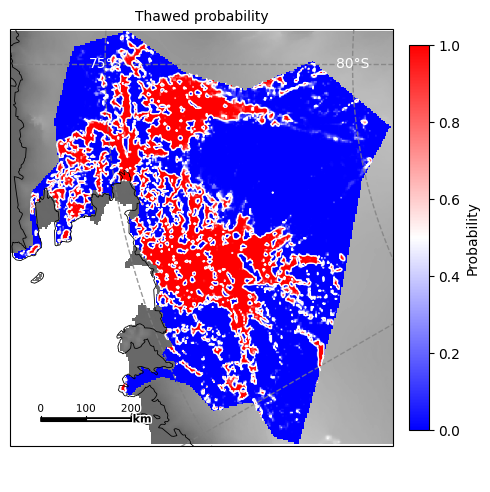

In [35]:
# compute thawed probability. This is defined by the fraction of samples that are within epsilon degree of PMP
def compute_thawed_probability(Tb_samples, pmp, epsilon=1):
    """
    Parameters
    ----------
    Tb_samples : (n_samples, n_pixels)  – posterior samples, spatially flattened
    pmp        : (nx, ny) or (n_pixels,) – pressure melting point
    epsilon    : float – tolerance in K

    Returns
    -------
    thawed_probability : (n_pixels,) – fraction of samples within epsilon of PMP
    """
    pmp_flat   = pmp.ravel()                          # (n_pixels,)
    # Tb_samples : (n_samples, n_pixels)  ✅ shapes now align on axis=1
    diff       = np.abs(pmp_flat[np.newaxis, :] - Tb_samples)   # (n_samples, n_pixels)
    thawed_count = np.sum(diff <= epsilon, axis=0)               # (n_pixels,)
    return thawed_count / Tb_samples.shape[0]


thawed_probability = compute_thawed_probability(Tb_samples, pmp, epsilon=1).reshape(nx, ny)
thawed_probability[aux_data['mask']==0] = np.nan
thawed_prob_data = dict(
    x = xs_ase,
    y = ys_ase,
    data = thawed_probability,
    vmin = 0,
    vmax = 1,
    cmap = 'bwr',
    contour_data = dTpmp_mean, 
    contour_levels = [1],
    title = 'Thawed probability',
    cb_label = 'Probability'
)
plotit.plot((thawed_prob_data,), background)